# 02b: Why Buffit Beats LPM — A Visual Explanation

**Audience**: Shimizu (and future readers)  
**Dataset**: MY (Shimizu 20260305) — the most dramatic case (LPM: 0.987, Buffit: 0.529)  
**Key message**: LPM and buffit both try to find buffer frames, but buffit does it at the right level of the data hierarchy.

## The core question

> "Is frame $j$ a buffer frame (protein not yet eluted) or a protein frame?"

This is a **column-level question** — it depends on when the protein elutes, not on the intensity at a particular $q$.  
LPM answers it **per q-row** from noisy 1D slices.  
Buffit answers it **once** from $M.\mathrm{sum}(\mathrm{axis}=0)$, which gains $\sqrt{N_q}$ in SNR (~31× for a 984-row matrix).

---

## Four figures

1. **Classification step** — the summed elution makes buffer frames unambiguous  
2. **Per-row baselines** — LPM anchors wander; buffit stays consistent  
3. **Corrected matrix** — LPM overcorrects in the inter-peak valley; buffit does not  
4. **positive_ratio per frame** — the scoring consequence of the overcorrection


In [ ]:
import os
import io
import contextlib
import numpy as np
import matplotlib.pyplot as plt
from molass.DataObjects import SecSaxsData as SSD

DATA_ROOT = r"C:\Users\takahashi\Dropbox\MOLASS\DATA\20260305"

ssd = SSD(os.path.join(DATA_ROOT, 'MY'))
xr = ssd.trimmed_copy().xr
M  = xr.M      # shape: (N_q, N_frames)
jv = xr.jv     # frame indices
iv = xr.iv     # q values

# --- Compute LPM (linear, adaptive p_final) baseline ---
xr.baseline_method = 'linear'
B_lpm = xr.get_baseline2d()

# --- Compute buffit baseline ---
THRESHOLD = 0.10
xr.baseline_method = 'buffit'
B_buf = xr.get_baseline2d(threshold=THRESHOLD)

# --- Buffer mask (recompute for plotting) ---
elution_sum  = M.sum(axis=0)
elution_norm = elution_sum / elution_sum.max()
buf_mask     = elution_norm < THRESHOLD

# --- positive_ratio helpers ---
def compute_positive_ratio(I):
    N = I.shape[0]
    y05, y95 = np.percentile(I, [5, 95])
    if y05 > 0:
        dy = (y95 - y05) / (N - 1)
        weights = np.arange(y95, y05 - dy / 10, -dy)
    else:
        weights = np.ones(N)
    weights /= np.sum(weights)
    return np.sum(weights[I > 0])

def compute_ratios(M_corr):
    return np.array([compute_positive_ratio(M_corr[:, j]) for j in range(M_corr.shape[1])])

ratios_lpm = compute_ratios(M - B_lpm)
ratios_buf = compute_ratios(M - B_buf)

print(f"MY XR matrix: {M.shape[0]} q-points × {M.shape[1]} frames")
print(f"Buffer frames (threshold={THRESHOLD}): {buf_mask.sum()} / {len(jv)}")
print(f"mean positive_ratio — LPM: {ratios_lpm.mean():.3f}   Buffit: {ratios_buf.mean():.3f}")


zeros at the angular ends of error data have been replaced with the adjacent values.


MY XR matrix: 973 q-points × 540 frames
Buffer frames (threshold=0.1): 428 / 540
mean positive_ratio — LPM: 0.987   Bufmask: 0.529


## Figure 1 — The classification step

MY has **two resolved elution peaks** (protein components) with a valley between them.  
The summed elution $\sum_q M_{q,j}$ makes the buffer region (before the first peak and after the second) unambiguous —  
a simple threshold at 10% of peak cleanly selects buffer frames.  
LPM must infer this from each q-row individually, with far lower SNR.


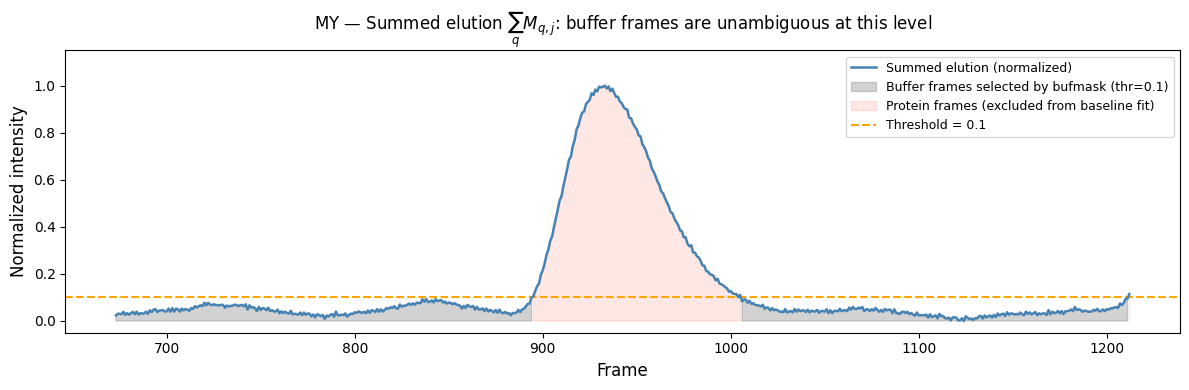

Saved: 02b_fig1_classification.png


In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(jv, elution_norm, color='steelblue', lw=1.8, label='Summed elution (normalized)', zorder=3)
ax.fill_between(jv, 0, elution_norm,
                where=buf_mask, alpha=0.35, color='gray',
                label=f'Buffer frames selected by buffit (thr={THRESHOLD})')
ax.fill_between(jv, 0, elution_norm,
                where=~buf_mask, alpha=0.15, color='tomato',
                label='Protein frames (excluded from baseline fit)')
ax.axhline(THRESHOLD, color='orange', lw=1.5, linestyle='--',
           label=f'Threshold = {THRESHOLD}')

ax.set_xlabel('Frame', fontsize=12)
ax.set_ylabel('Normalized intensity', fontsize=12)
ax.set_title('MY — Summed elution $\\sum_q M_{q,j}$: buffer frames are unambiguous at this level',
             fontsize=12)
ax.set_ylim(-0.05, 1.15)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('02b_fig1_classification.png', dpi=150)
plt.show()
print("Saved: 02b_fig1_classification.png")


## Figure 2 — Per-row baselines

For four representative q-rows, compare the raw elution, the LPM baseline, and the buffit baseline.  
Note how the **LPM baseline tilts upward** toward the inter-peak valley in low-SNR rows — it mistakes the  
valley for "low percentile" and anchors there.  
The **buffit baseline** uses only the true buffer frames (beginning and end), remaining flat and consistent.


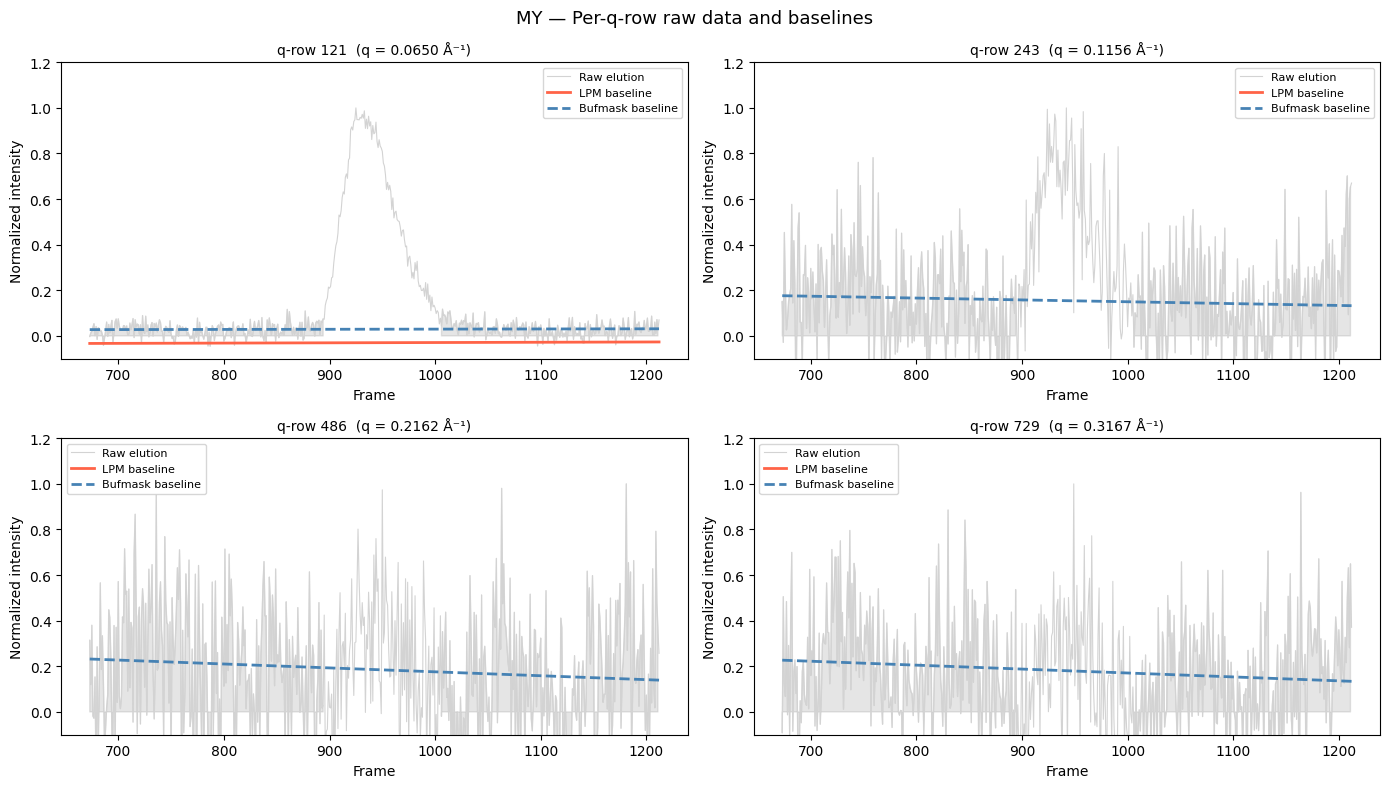

Saved: 02b_fig2_per_row_baselines.png


In [ ]:
# Choose 4 q-rows evenly spaced across the q-range
nq = M.shape[0]
q_indices = [nq // 8, nq // 4, nq // 2, 3 * nq // 4]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('MY — Per-q-row raw data and baselines', fontsize=13)

for ax, qi in zip(axes.flat, q_indices):
    y = M[qi, :]
    y_norm = y / y.max() if y.max() > 0 else y
    b_lpm_norm = B_lpm[qi, :] / y.max() if y.max() > 0 else B_lpm[qi, :]
    b_buf_norm = B_buf[qi, :] / y.max() if y.max() > 0 else B_buf[qi, :]

    ax.plot(jv, y_norm, color='lightgray', lw=0.8, label='Raw elution')
    ax.fill_between(jv, 0, y_norm, where=buf_mask, alpha=0.2, color='gray')
    ax.plot(jv, b_lpm_norm, color='tomato', lw=2.0, label='LPM baseline')
    ax.plot(jv, b_buf_norm, color='steelblue', lw=2.0, linestyle='--', label='Buffit baseline')

    ax.set_title(f'q-row {qi}  (q = {iv[qi]:.4f} Å⁻¹)', fontsize=10)
    ax.set_xlabel('Frame')
    ax.set_ylabel('Normalized intensity')
    ax.legend(fontsize=8)
    ax.set_ylim(-0.1, 1.2)

plt.tight_layout()
plt.savefig('02b_fig2_per_row_baselines.png', dpi=150)
plt.show()
print("Saved: 02b_fig2_per_row_baselines.png")


## Figure 3 — Corrected matrix: LPM undercorrects; buffit correctly zeroes the buffer

Side-by-side 2D view of $M - B$. Colormap: **red = positive, blue = negative, white = zero**.  
    **LPM panel** (0.9% negative): the matrix is uniformly red — the baseline was drawn *too low*,  
    leaving the buffer-level scattering uncancelled. The corrected matrix still contains a positive
    background pedestal everywhere.  
    **Buffit panel** (47% negative): the buffer region is blue/white (correctly zeroed — symmetric noise),
    and only the protein peak stands out as dark red. 47% negative ≈ ideal for symmetric noise.


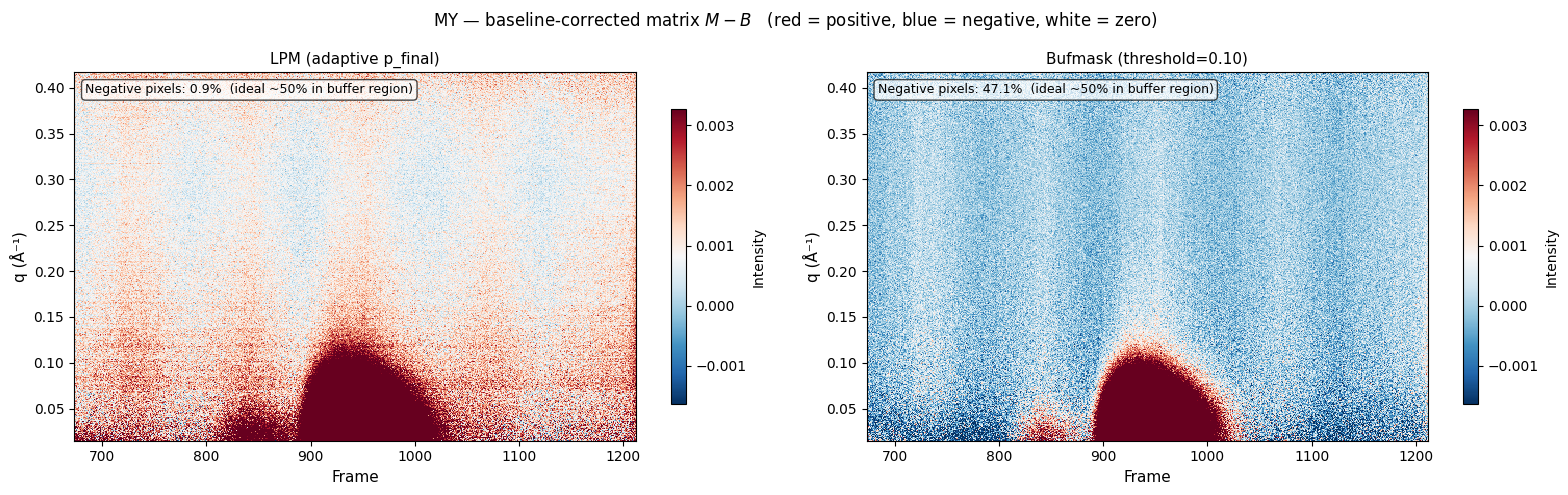

Saved: 02b_fig3_corrected_matrix.png


In [ ]:
M_lpm = M - B_lpm
M_buf = M - B_buf

# Symmetric colour scale around zero; clip at 95th percentile of positive signal
vmax = np.percentile(M[~np.isnan(M)], 95)
vmin = -vmax * 0.5

extent = [jv[0], jv[-1], iv[0], iv[-1]]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('MY — baseline-corrected matrix $M - B$   (red = positive, blue = negative, white = zero)',  
             fontsize=12)

for ax, corr, title in zip(axes,
                            [M_lpm, M_buf],
                            ['LPM (adaptive p_final)', 'Buffit (threshold=0.10)']):
    im = ax.imshow(corr, aspect='auto', origin='lower',
                   extent=extent, vmin=vmin, vmax=vmax,
                   cmap='RdBu_r', interpolation='nearest')
    ax.set_xlabel('Frame', fontsize=11)
    ax.set_ylabel('q (Å⁻¹)', fontsize=11)
    ax.set_title(title, fontsize=11)
    plt.colorbar(im, ax=ax, shrink=0.8, label='Intensity')

    # Annotate negative fraction
    neg_pct = 100 * (corr < 0).mean()
    pos_label = f'Negative pixels: {neg_pct:.1f}%  (ideal ~50% in buffer region)'
    ax.text(0.02, 0.97, pos_label,  
            transform=ax.transAxes, fontsize=9, va='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.savefig('02b_fig3_corrected_matrix.png', dpi=150)
plt.show()
print("Saved: 02b_fig3_corrected_matrix.png")


## Figure 4 — positive_ratio per frame

`positive_ratio` is the quality gate used by the Guinier analysis:  
frames where this ratio is close to 1 have almost all intensities positive → the
baseline was subtracted *too little* (or not at all); frames near 0.5 are ideal
(half positive, half negative, centred on zero).  

Here: the LPM trace sits near 1.0 throughout the elution peak, meaning the corrected
intensity is **biased positive** — the baseline was drawn too low.  
The buffit trace drops to near 0.5 in the peak region: the baseline correctly
removes the background, leaving a symmetrically distributed residual.


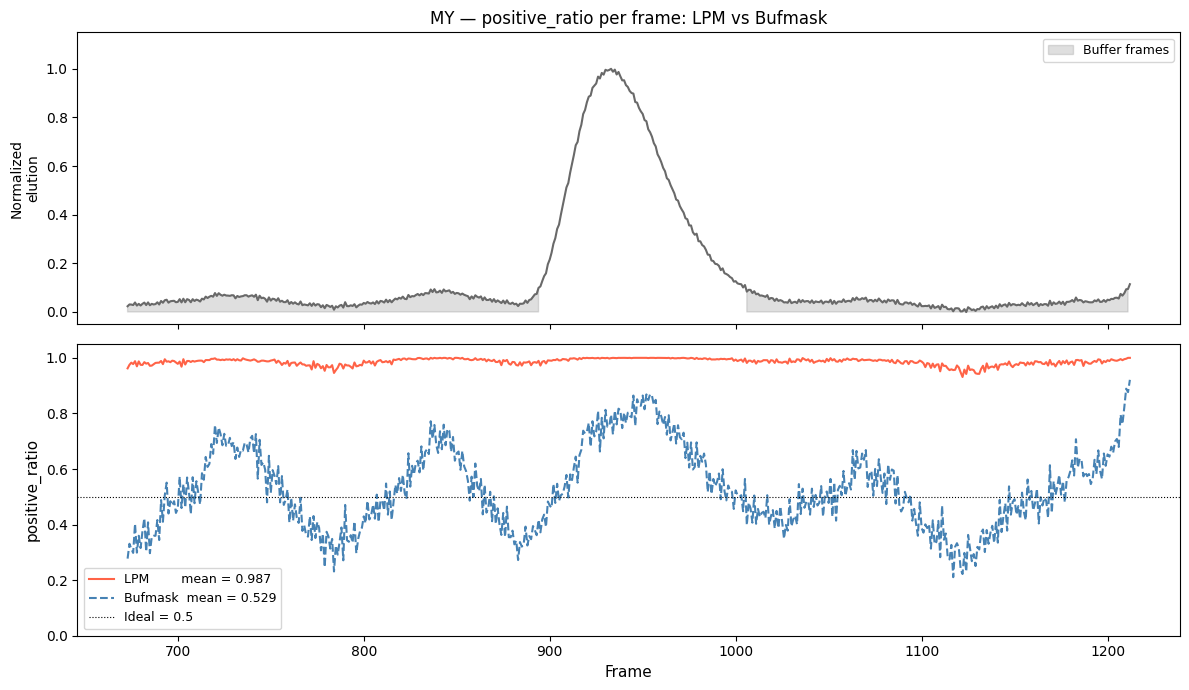

Saved: 02b_fig4_positive_ratio.png

Summary for MY:
  LPM    mean positive_ratio = 0.987  (ideal: 0.5)
  Bufmask mean positive_ratio = 0.529  (ideal: 0.5)
  Improvement = +0.458


In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# Top: elution context
axes[0].plot(jv, elution_norm, color='dimgray', lw=1.5)
axes[0].fill_between(jv, 0, elution_norm, where=buf_mask, alpha=0.25, color='gray',
                     label='Buffer frames')
axes[0].set_ylabel('Normalized\nelution', fontsize=10)
axes[0].set_title('MY — positive_ratio per frame: LPM vs Buffit', fontsize=12)
axes[0].legend(fontsize=9)
axes[0].set_ylim(-0.05, 1.15)

# Bottom: positive_ratio
axes[1].plot(jv, ratios_lpm, color='tomato', lw=1.5,
             label=f'LPM       mean = {ratios_lpm.mean():.3f}')
axes[1].plot(jv, ratios_buf, color='steelblue', lw=1.5, linestyle='--',
             label=f'Buffit    mean = {ratios_buf.mean():.3f}')
axes[1].axhline(0.5, color='black', lw=0.8, linestyle=':', label='Ideal = 0.5')
axes[1].set_xlabel('Frame', fontsize=11)
axes[1].set_ylabel('positive_ratio', fontsize=11)
axes[1].set_ylim(0, 1.05)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('02b_fig4_positive_ratio.png', dpi=150)
plt.show()
print("Saved: 02b_fig4_positive_ratio.png")

print(f"\nSummary for MY:")
print(f"  LPM    mean positive_ratio = {ratios_lpm.mean():.3f}  (ideal: 0.5)")
print(f"  Buffit mean positive_ratio = {ratios_buf.mean():.3f}  (ideal: 0.5)")
print(f"  Improvement = {ratios_lpm.mean() - ratios_buf.mean():+.3f}")


## Summary

| | LPM | Buffit |
|--|--|--|
| **Where classification happens** | Per q-row (low SNR) | Summed elution (×√N_q SNR boost) |
| **Anchor frame selection** | Varies row-by-row; can pick inter-peak valley | Same buffer frames for every q-row |
| **MY positive_ratio (mean)** | 0.987 (near 1 = undercorrection: baseline drawn below true buffer level, residuals biased positive) | 0.529 (near ideal 0.5) |
| **Why MY is so extreme** | Double-peak elution with low SNR per row: LPM anchors at noise minimum, far below true buffer level | Summed elution clearly separates buffer from both peaks; baseline anchored at true buffer level |

**Take-home**: buffit does not introduce new assumptions — both methods assume buffer frames are low-intensity.  
Buffit simply makes that classification at the level where it can be made reliably (the full-matrix sum),  
rather than at the level where it is most ambiguous (individual q-rows).
